## Imports

In [1]:
import matplotlib.pyplot as plt

In [2]:
from collections import Counter
import random

In [3]:
import torch
from torch import optim
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split

In [4]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms

## Configs

### cuda Check

In [5]:
print("PyTorch version:", torch.__version__)
cudaAvailable = torch.cuda.is_available()
print("CUDA available:", cudaAvailable)
if cudaAvailable:
    print("GPU name:", torch.cuda.get_device_name(0))
    print("CUDA version (PyTorch):", torch.version.cuda)
    print("cuDNN version:", torch.backends.cudnn.version())

PyTorch version: 2.8.0+cu126
CUDA available: True
GPU name: NVIDIA GeForce RTX 3050 6GB Laptop GPU
CUDA version (PyTorch): 12.6
cuDNN version: 91002


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
device

device(type='cuda')

### Data

In [8]:
data_dir = "dataset/"
img_size = 128
batch_size = 16
seq_len = 3    
train_split = 0.8    

### ProgNet Paramaters

In [9]:
feature_dim = 512
hidden_dim = 256
num_layers = 2
dropout = 0.3

### Training Parameters

In [10]:
epochs = 20
learning_rate = 0.001
weight_decay = 1e-4
scheduler_type = "cosine"
label_smoothing = 0.05

### Saving the Model

In [11]:
seed = 42
torch.manual_seed(seed)
random.seed(seed)

save_path = "cane_sight.pth"

### Transform

In [12]:
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

## Loading Image Data

### Sequential Wrapper of Dataset

In [13]:
class SequenceDataset(Dataset):
    def __init__(self, root, transform, seq_len=3):
        self.dataset = datasets.ImageFolder(root=root, transform=transform)
        self.classes = self.dataset.classes
        self.seq_len = seq_len
        self.class_to_idx = self.dataset.class_to_idx

        # Group images by class
        self.class_to_images = {}
        for idx, (path, label) in enumerate(self.dataset.samples):
            if label not in self.class_to_images:
                self.class_to_images[label] = []
            self.class_to_images[label].append(idx)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        # pick main sample
        img, label = self.dataset[idx]

        # sample extra images from the same class
        choices = random.choices(self.class_to_images[label], k=self.seq_len-1)
        imgs = [img] + [self.dataset[i][0] for i in choices]

        # stack into (seq_len, C, H, W)
        imgs = torch.stack(imgs, dim=0)
        return imgs, label

### Load Data

In [14]:
dataset = SequenceDataset(root=data_dir, transform=transform, seq_len=seq_len)
class_names = dataset.classes
num_classes = len(class_names)

### Train and Test Split

In [15]:
train_size = int(train_split * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [16]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [17]:
print(f"Classes: {class_names}")
print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")

Classes: ['BacterialBlights', 'Healthy', 'Mosaic', 'RedRot', 'Rust', 'Yellow']
Train: 15940 | Test: 3986


## Distribution of Images

### Class-Wise Distribution

In [18]:
class_counts = Counter(dataset.dataset.targets)
classes = dataset.classes

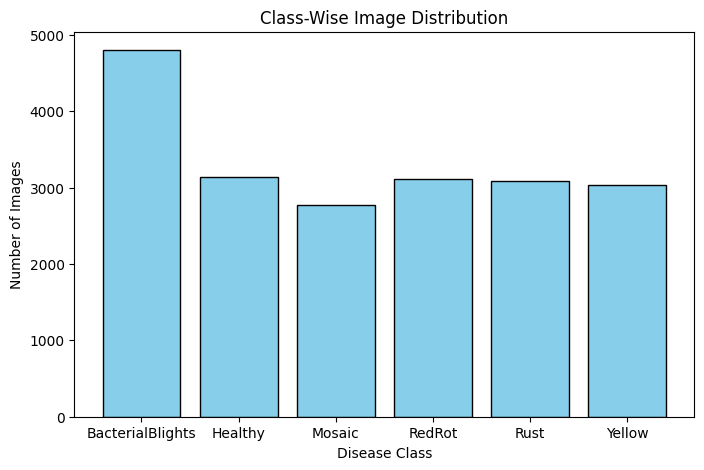

In [19]:
counts = [class_counts[i] for i in range(len(classes))]

plt.figure(figsize=(8,5))
plt.bar(classes, counts, color="skyblue", edgecolor="black")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.title("Class-Wise Image Distribution")
plt.show()

### Class-Wise Train-Test Distribution

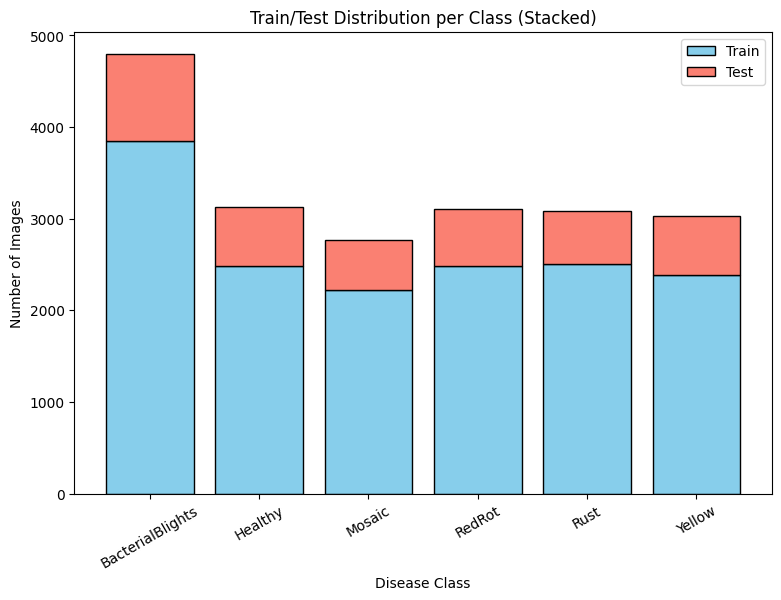

In [20]:
train_counts = Counter([dataset.dataset.targets[i] for i in train_dataset.indices])
test_counts  = Counter([dataset.dataset.targets[i] for i in test_dataset.indices])

train_vals = [train_counts[i] for i in range(len(classes))]
test_vals  = [test_counts[i] for i in range(len(classes))]

x = range(len(classes))
plt.figure(figsize=(9,6))
plt.bar(x, train_vals, label="Train", color="skyblue", edgecolor="black")
plt.bar(x, test_vals, bottom=train_vals, label="Test", color="salmon", edgecolor="black")

plt.xticks(x, classes, rotation=30)
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.title("Train/Test Distribution per Class (Stacked)")
plt.legend()
plt.show()

### Image Distribution Summary

In [21]:
for image_class, count in class_counts.items():
    print(f"{dataset.classes[image_class]}: {count}")

print(f"\nTotal images: {len(dataset)}")

BacterialBlights: 4800
Healthy: 3132
Mosaic: 2772
RedRot: 3108
Rust: 3084
Yellow: 3030

Total images: 19926


## Model

### SymNet - CNN Symptom Feature Extractor

In [22]:
def conv_block(cin, cout, k=3, s=1, p=1):
    return nn.Sequential(
        nn.Conv2d(cin, cout, kernel_size=k, stride=s, padding=p, bias=False),
        nn.BatchNorm2d(cout),
        nn.ReLU(inplace=True),
    )

In [23]:
class SymNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            conv_block(3, 32),
            conv_block(32, 32),
            nn.MaxPool2d(2),
        )
        self.stage2 = nn.Sequential(
            conv_block(32, 64),
            conv_block(64, 64),
            nn.MaxPool2d(2),
        )
        self.stage3 = nn.Sequential(
            conv_block(64, 128),
            conv_block(128, 128),
            nn.MaxPool2d(2),
        )
        self.stage4 = nn.Sequential(
            conv_block(128, 256),
            conv_block(256, 256),
            nn.MaxPool2d(2),
        )
        self.stage5 = nn.Sequential(
            conv_block(256, 512),
            conv_block(512, 512),
            nn.AdaptiveAvgPool2d(1),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.stage5(x)
        return x.view(x.size(0), -1) 

### ProgNet - LSTM Sequence Modeler

In [24]:
class ProgNet(nn.Module):
    def __init__(self, feature_dim=feature_dim, hidden_dim=hidden_dim, num_layers=num_layers,
                 num_classes=num_classes, dropout=dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=feature_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True
        )
        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, num_classes)
        )

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        last_hidden = torch.cat((hn[-2], hn[-1]), dim=1)
        return self.fc(last_hidden)

### CaneSight - SymNet + ProgNet

In [25]:
class CaneSight(nn.Module):
    def __init__(self, symnet, prognet):
        super().__init__()
        self.symnet = symnet
        self.prognet = prognet

    def forward(self, x_seq):
        batch_size, seq_len, C, H, W = x_seq.size()
        features = []

        for t in range(seq_len):
            img = x_seq[:, t, :, :, :]
            feat = self.symnet(img)
            features.append(feat)

        features = torch.stack(features, dim=1)
        return self.prognet(features)

## Training Setup

In [26]:
symnet = SymNet()
prognet = ProgNet()
model = CaneSight(symnet, prognet).to(device)

In [27]:
criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

In [28]:
if scheduler_type == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
elif scheduler_type == "step":
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
else:
    scheduler = None

### Training Function

In [29]:
def train_one_epoch(loader):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        total_correct += (outputs.argmax(1) == labels).sum().item()
        total += imgs.size(0)
    return total_loss/total, total_correct/total

### Testing Function

In [30]:
def test(loader):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * imgs.size(0)
            total_correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss/total, total_correct/total

### Training Loop

In [31]:
best_acc = 0.0
for epoch in range(1, epochs + 1):
    train_loss, train_acc = train_one_epoch(train_loader)
    test_loss, test_acc = test(test_loader)
    if scheduler is not None:
        scheduler.step()

    print(f"Epoch {epoch:02d}/{epochs} | "
          f"Train Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}")

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), save_path)

print(f"\nTraining Complete.\nBest Test Accuracy: {best_acc:.4f}")

Epoch 01/20 | Train Loss: 0.9304, Accuracy: 0.6708 | Test Loss: 0.6855, Accuracy: 0.8041
Epoch 02/20 | Train Loss: 0.7161, Accuracy: 0.7942 | Test Loss: 0.5759, Accuracy: 0.8590
Epoch 03/20 | Train Loss: 0.5781, Accuracy: 0.8580 | Test Loss: 0.5547, Accuracy: 0.8402
Epoch 04/20 | Train Loss: 0.5193, Accuracy: 0.8870 | Test Loss: 0.4431, Accuracy: 0.9197
Epoch 05/20 | Train Loss: 0.4691, Accuracy: 0.9087 | Test Loss: 0.3522, Accuracy: 0.9543
Epoch 06/20 | Train Loss: 0.4234, Accuracy: 0.9272 | Test Loss: 0.3323, Accuracy: 0.9671
Epoch 07/20 | Train Loss: 0.3888, Accuracy: 0.9425 | Test Loss: 0.3247, Accuracy: 0.9656
Epoch 08/20 | Train Loss: 0.3751, Accuracy: 0.9469 | Test Loss: 0.3066, Accuracy: 0.9762
Epoch 09/20 | Train Loss: 0.3518, Accuracy: 0.9579 | Test Loss: 0.2843, Accuracy: 0.9844
Epoch 10/20 | Train Loss: 0.3369, Accuracy: 0.9629 | Test Loss: 0.2953, Accuracy: 0.9774
Epoch 11/20 | Train Loss: 0.3227, Accuracy: 0.9674 | Test Loss: 0.2719, Accuracy: 0.9902
Epoch 12/20 | Train L